In [28]:
import pandas as pd
df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,unnamed_col,record_timestamp,index_copy,notes
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,...,Express,Yes,Yes,46,Credit Card,Monthly,NaN,2024-01-01 00:00:00,0,NaN
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,...,Store Pickup,Yes,Yes,7,PayPal,Weekly,NaN,2024-01-01 00:00:00,1,NaN
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,...,Next Day Air,NaN,No,10,Venmo,Bi-Weekly,NaN,2024-01-01 00:00:00,2,NaN
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,...,Next Day Air,Yes,Yes,10,PayPal,Weekly,NaN,2024-01-01 00:00:00,3,NaN
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,...,Next Day Air,No,No,28,Bank Transfer,Every 3 Months,NaN,2024-01-01 00:00:00,4,NaN


In [29]:
df=df.drop(columns=["record_timestamp","unnamed_col","index_copy","notes"])

In [30]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,2.6,No,Cash,Express,Yes,Yes,46,Credit Card,Monthly
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,4.4,No,Bank Transfer,Store Pickup,Yes,Yes,7,PayPal,Weekly
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,4.9,No,Credit Card,Next Day Air,NaN,No,10,Venmo,Bi-Weekly
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,2.9,No,Debit Card,Next Day Air,Yes,Yes,10,PayPal,Weekly
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,2.9,No,PayPal,Next Day Air,No,No,28,Bank Transfer,Every 3 Months


In [31]:
df.duplicated().sum()

np.int64(35)

In [32]:
df=df.drop_duplicates()
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1072,61.0,Male,Hat,Accessories,81,Pennsylvania,M,Beige,Summer,2.6,No,Cash,Express,Yes,Yes,46,Credit Card,Monthly
1,1201,27.0,Male,Coat,Outerwear,22,Connecticut,XL,Black,Winter,4.4,No,Bank Transfer,Store Pickup,Yes,Yes,7,PayPal,Weekly
2,2719,22.0,Female,Shorts,Clothing,90,Virginia,M,Peach,Winter,4.9,No,Credit Card,Next Day Air,NaN,No,10,Venmo,Bi-Weekly
3,1290,35.0,Male,Jacket,Outerwear,24,New Hampshire,M,Red,Fall,2.9,No,Debit Card,Next Day Air,Yes,Yes,10,PayPal,Weekly
4,3688,34.0,Female,Shirt,Clothing,44,Arkansas,L,Lavender,Summer,2.9,No,PayPal,Next Day Air,No,No,28,Bank Transfer,Every 3 Months


In [33]:
df.isnull().sum()

Customer ID                   0
Age                         204
Gender                      169
Item Purchased                0
Category                      0
Purchase Amount (USD)         0
Location                    250
Size                          0
Color                         0
Season                        0
Review Rating               326
Subscription Status         165
Payment Method                0
Shipping Type               181
Discount Applied            274
Promo Code Used               0
Previous Purchases            0
Preferred Payment Method      0
Frequency of Purchases        0
dtype: int64

In [34]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3982.000000,3778.000000,3982.000000,3656.000000,3982.000000
mean,1952.300352,46.606141,59.610748,3.746335,25.347313
std,1125.128474,51.362258,23.802707,0.718170,14.445827
min,1.000000,18.000000,-1.000000,2.500000,1.000000
25%,979.250000,31.000000,38.000000,3.100000,13.000000
50%,1951.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.750000,57.000000,80.750000,4.400000,38.000000
max,3900.000000,999.000000,100.000000,5.000000,50.000000


In [35]:
df["Age"]=df["Age"].replace(999, int(df[df["Age"] != 999]["Age"].mean()))
df["Age"]=df["Age"].replace(-1, int(df[df["Age"] != -1]["Age"].mean()))

In [36]:
df["Purchase Amount (USD)"]=df["Purchase Amount (USD)"].replace(-1, int(df[df["Purchase Amount (USD)"] != -1]["Purchase Amount (USD)"].mean()))


In [37]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3982.000000,3778.000000,3982.000000,3656.000000,3982.000000
mean,1952.300352,44.078348,59.731291,3.746335,25.347313
std,1125.128474,15.171954,23.646833,0.718170,14.445827
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,979.250000,31.000000,39.000000,3.100000,13.000000
50%,1951.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.750000,57.000000,80.750000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [38]:
df.describe(include="str")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3813,3982,3982,3732,3982,3982,3982,3817,3982,3801,3708,3982,3982,3982
unique,4,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Pants,Clothing,California,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2199,177,1781,95,1790,182,1020,2786,706,659,2113,2272,687,599


In [39]:
df["Gender"]=df["Gender"].replace("male","Male")
df["Gender"]=df["Gender"].replace("female","Female")
df["Gender"]=df["Gender"].replace("FEMALE","Female")
df.describe(include="str")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3813,3982,3982,3732,3982,3982,3982,3817,3982,3801,3708,3982,3982,3982
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Pants,Clothing,California,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2590,177,1781,95,1790,182,1020,2786,706,659,2113,2272,687,599


In [40]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Review Rating"]=df["Review Rating"].fillna(df["Review Rating"].mean())
df["Gender"]=df["Gender"].fillna(df["Gender"].mode().item())
df["Location"]=df["Location"].fillna(df["Location"].mode().item())
df["Subscription Status"]=df["Subscription Status"].fillna(df["Subscription Status"].mode().item())
df["Shipping Type"]=df["Shipping Type"].fillna(df["Shipping Type"].mode().item())
df["Discount Applied"]=df["Discount Applied"].fillna(df["Discount Applied"].mode().item())
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [41]:
import matplotlib.pyplot as plt
import streamlit as st

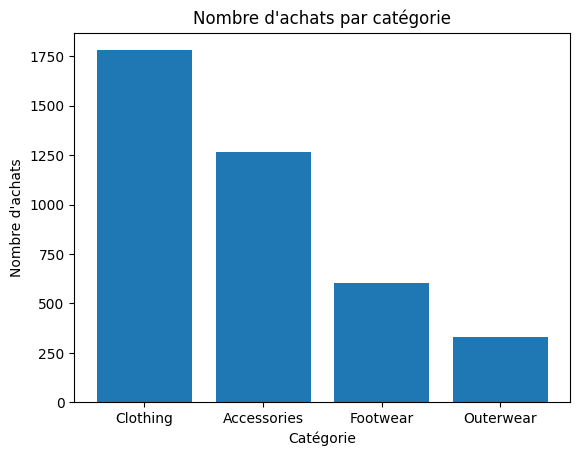

In [42]:
cat_counts = df['Category'].value_counts()
plt.bar(cat_counts.index, cat_counts.values)
plt.title("Nombre d'achats par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'achats")
plt.show()

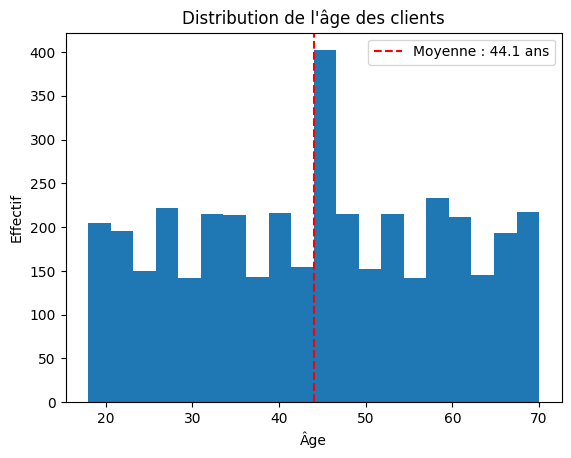

In [43]:
plt.hist(df['Age'], bins=20)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['Age'].mean():.1f} ans")
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.legend()
plt.show()

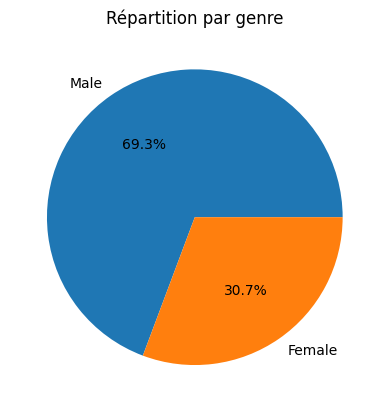

In [44]:
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Répartition par genre")
plt.show()

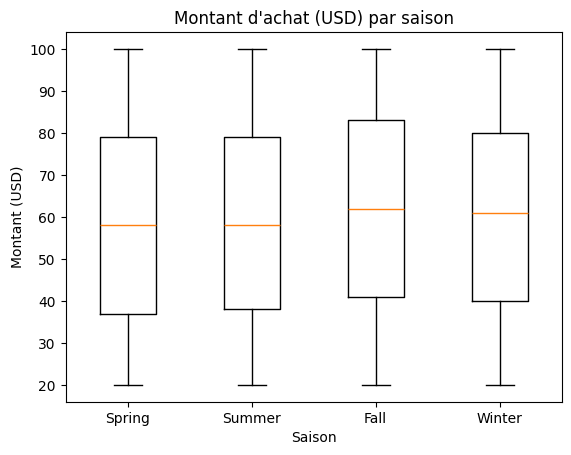

In [45]:
spring = df[df['Season'] == 'Spring']['Purchase Amount (USD)']
summer = df[df['Season'] == 'Summer']['Purchase Amount (USD)']
fall   = df[df['Season'] == 'Fall'  ]['Purchase Amount (USD)']
winter = df[df['Season'] == 'Winter']['Purchase Amount (USD)']
plt.boxplot([spring, summer, fall, winter], tick_labels=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title("Montant d'achat (USD) par saison")
plt.xlabel("Saison")
plt.ylabel("Montant (USD)")
plt.show()

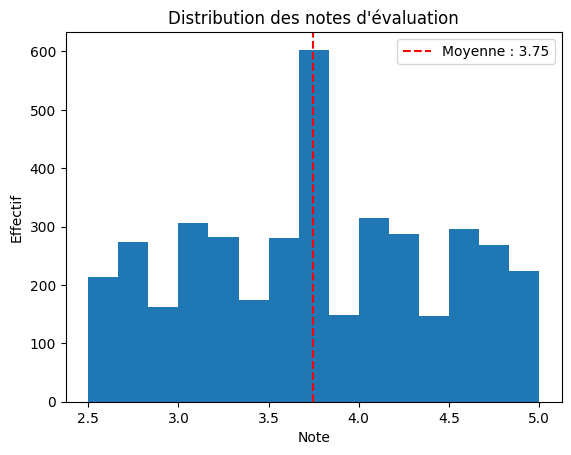

In [46]:
plt.hist(df['Review Rating'], bins=15)
plt.axvline(df['Review Rating'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['Review Rating'].mean():.2f}")
plt.title("Distribution des notes d'évaluation")
plt.xlabel("Note")
plt.ylabel("Effectif")
plt.legend()
plt.show()

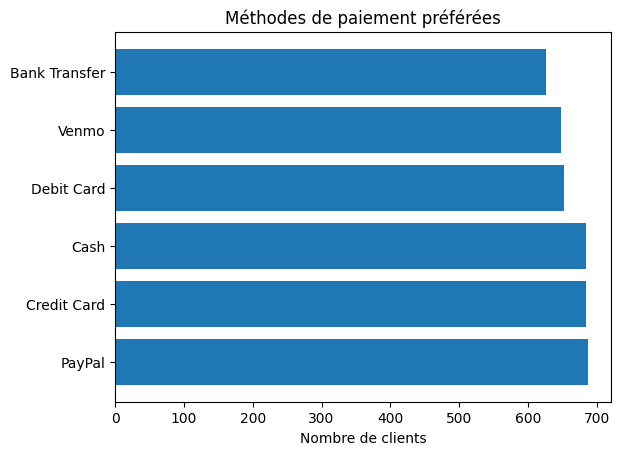

In [47]:
pay_counts = df['Preferred Payment Method'].value_counts()
plt.barh(pay_counts.index, pay_counts.values)
plt.title("Méthodes de paiement préférées")
plt.xlabel("Nombre de clients")
plt.show()

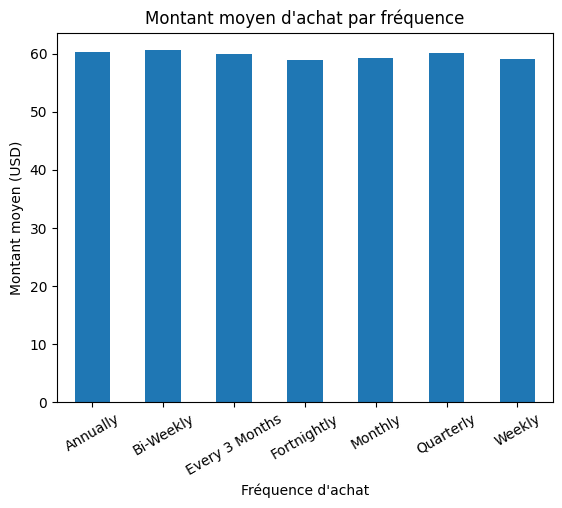

In [48]:
freq_avg = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean()
freq_avg.plot(kind='bar')
plt.title("Montant moyen d'achat par fréquence")
plt.xlabel("Fréquence d'achat")
plt.ylabel("Montant moyen (USD)")
plt.xticks(rotation=30)
plt.show()

In [49]:
st.set_page_config(
    page_title="Shopping Trends Dashboard",
    page_icon="🛍️",
    layout="wide"
)

st.title(" Shopping Trends Dashboard")
st.markdown("Analyse interactive des tendances d'achat — *{:,} clients* après nettoyage.".format(len(df)))
st.divider()


st.sidebar.header(" Filtres")

genders  = st.sidebar.multiselect("Genre",   sorted(df["Gender"].unique()),   default=sorted(df["Gender"].unique()))
cats     = st.sidebar.multiselect("Catégorie", sorted(df["Category"].unique()), default=sorted(df["Category"].unique()))
seasons  = st.sidebar.multiselect("Saison",  sorted(df["Season"].unique()),   default=sorted(df["Season"].unique()))
sub_only = st.sidebar.checkbox("Abonnés uniquement", value=False)

fdf = df[
    df["Gender"].isin(genders) &
    df["Category"].isin(cats)  &
    df["Season"].isin(seasons)
]
if sub_only:
    fdf = fdf[fdf["Subscription Status"] == "Yes"]


k1, k2, k3, k4 = st.columns(4)
k1.metric("Clients",            f"{len(fdf):,}")
k2.metric("Achat moyen (USD)",  f"{fdf['Purchase Amount (USD)'].mean():.2f}")
k3.metric("Note moyenne",       f"{fdf['Review Rating'].mean():.2f} / 5")
k4.metric("Âge moyen",          f"{fdf['Age'].mean():.1f} ans")
st.divider()


c1, c2 = st.columns(2)

with c1:
    st.subheader("Achats par catégorie")
    fig, ax = plt.subplots(figsize=(6, 4))
    cc = fdf["Category"].value_counts()
    bars = ax.bar(cc.index, cc.values, color=["#4C72B0","#DD8452","#55A868","#C44E52"], edgecolor="white")
    ax.bar_label(bars, padding=3, fontsize=10, fontweight="bold")
    ax.set_ylabel("Nombre d'achats")
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylim(0, cc.max() * 1.12)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

with c2:
    st.subheader("Répartition par genre")
    fig, ax = plt.subplots(figsize=(5, 4))
    gc = fdf["Gender"].value_counts()
    ax.pie(gc.values, labels=gc.index, autopct="%1.1f%%",
           colors=["#4C72B0","#DD8452"], startangle=90,
           wedgeprops={"linewidth":2,"edgecolor":"white"},
           textprops={"fontsize":13})
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


c3, c4 = st.columns(2)

with c3:
    st.subheader("Distribution de l'âge")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(fdf["Age"], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(fdf["Age"].mean(), color="#C44E52", linestyle="--", linewidth=1.8,
               label=f"Moy. {fdf['Age'].mean():.1f} ans")
    ax.set_xlabel("Âge"); ax.set_ylabel("Effectif")
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=10)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

with c4:
    st.subheader("Montant d'achat par saison")
    fig, ax = plt.subplots(figsize=(6, 4))
    s_order = [s for s in ["Spring","Summer","Fall","Winter"] if s in fdf["Season"].unique()]
    s_data  = [fdf[fdf["Season"]==s]["Purchase Amount (USD)"].dropna().values for s in s_order]
    bp = ax.boxplot(s_data, labels=s_order, patch_artist=True,
                    medianprops={"color":"white","linewidth":2})
    for patch, col in zip(bp["boxes"], ["#55A868","#DD8452","#C44E52","#4C72B0"]):
        patch.set_facecolor(col); patch.set_alpha(0.85)
    ax.set_xlabel("Saison"); ax.set_ylabel("Montant (USD)")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


c5, c6 = st.columns(2)

with c5:
    st.subheader("Distribution des notes")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(fdf["Review Rating"], bins=15, color="#55A868", edgecolor="white", alpha=0.85)
    ax.axvline(fdf["Review Rating"].mean(), color="#C44E52", linestyle="--", linewidth=1.8,
               label=f"Moy. {fdf['Review Rating'].mean():.2f}")
    ax.set_xlabel("Note"); ax.set_ylabel("Effectif")
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=10)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)

with c6:
    st.subheader("Méthodes de paiement préférées")
    fig, ax = plt.subplots(figsize=(6, 4))
    pc = fdf["Preferred Payment Method"].value_counts()
    bars = ax.barh(pc.index, pc.values,
                   color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860"],
                   edgecolor="white")
    ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
    ax.set_xlabel("Nombre de clients")
    ax.spines[["top","right"]].set_visible(False)
    ax.set_xlim(0, pc.max() * 1.12)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


st.divider()
st.subheader(" Données filtrées")
st.dataframe(fdf.reset_index(drop=True), use_container_width=True, height=300)


2026-05-02 23:01:21.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 23:01:21.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [50]:
!python -m jupyter nbconvert --to script "projet.ipynb"

[NbConvertApp] Converting notebook projet.ipynb to script
[NbConvertApp] Writing 8233 bytes to projet.py
